In [1]:
import os
import traceback
import numpy as np
import sys
sys.path.append('/home/ram/Pictures')

# Import all components from the package
from GPhIon import (
    load_simulation_data,
    CoordinateProcessor,
    TracerPropertyAnalyzer,
    VibrationAnalyzer,
    AmorphousSiteFinder,
    SiteAnalyzerMDA,
    JumpDiffusivityAnalyzer,
    CollectiveJumpAnalyzer,
    RDFAnalyzer,
    plot_taog_density,
    VanHoveAnalyzer,
    MigrationPathwayPlotter,
    ActivationEnergyAnalyzer,
    ConnectivityPlotter,
    CollectivePlotter,
    DisplacementPlotter,
    VanHovePlotter
)

/home/ram/software/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("="*80)
print("TAOG (Time-Averaged Occupancy Grid) Analysis")
print("="*80)

# --- 1. Define Parameters ---
project_folder = '/home/ram/Downloads/GO/test_package'
temperature = 400.0
dump_filename = 'pure_400.lammpstrj'
dump_filepath = os.path.join(project_folder, dump_filename)
# type_to_element = {1: 'S', 2: 'F', 3: 'O', 4: 'N', 5: 'C', 6: 'Li', 7: 'Zn', 8: 'H', 9: 'Co'}
type_to_element = {1: 'S', 2: 'F', 3: 'O', 4: 'N', 5: 'C', 6: 'Li', 7: 'Co', 8: 'H'}
diffusing_element = 'Li'
timestep_ps = 0.1        # Picosecond timestep 450:0.1,  400: 2.0
density_grid_resolution = 100
output_data_path = os.path.join(project_folder, "analysis_output")
diffusion_dimensionality = 3
ion_charge_z = 1.0
experimental_coll_dist = 6.0
experimental_coll_steps = None

# Ensure output directory exists
os.makedirs(output_data_path, exist_ok=True)

if not os.path.exists(dump_filepath):
    raise FileNotFoundError(f"CRITICAL ERROR: Trajectory file not found at '{dump_filepath}'")

# --- 2. Load Trajectory Data ---
print("\n🔄 Loading simulation data...")
sim_data_obj = load_simulation_data(
    dump_file=dump_filepath,
    type_to_element=type_to_element,
    diff_elem=diffusing_element,
    dt_ps=timestep_ps,
    temperature=temperature
)
print(f"✅ Loaded trajectory with {sim_data_obj.nr_steps} frames")
print(f" 📊 {sim_data_obj.nr_diffusing} diffusing {diffusing_element} atoms out of {sim_data_obj.nr_atoms} total")

# --- 3. Calculate Fractional Coordinates and Displacement ---
print("\n🔄 Calculating coordinates and displacement...")
coord_processor = CoordinateProcessor()
sim_data_obj = coord_processor.frac_and_disp(sim_data_obj)
print("✅ Coordinate processing complete")


TAOG (Time-Averaged Occupancy Grid) Analysis

🔄 Loading simulation data...
--- Stage 1: Reading LAMMPS Trajectory ---


/home/ram/software/miniconda3/lib/python3.12/site-packages/MDAnalysis/topology/LAMMPSParser.py:651: UserWarning: Guessed all Masses to 1.0
  warnings.warn("Guessed all Masses to 1.0")


DEBUG: Trajectory loaded with 1501 frames.
✅ Loaded trajectory with 1501 frames
 📊 48 diffusing Li atoms out of 3328 total

🔄 Calculating coordinates and displacement...
DEBUG: CoordinateProcessor instance created.
DEBUG: Calculating fractional coordinates and displacement...
DEBUG: Displacement calculation finished.
✅ Coordinate processing complete



🔄 Analyzing tracer properties from MSD...

--- Stage: Analyzing Tracer Properties (MSD) ---
-------------------------------------------
Calculating tracer diffusion and conductivity based on:
3 dimensional diffusion, and an ion with a charge of 1.0
Tracer diffusivity determined to be (in m^2/s): 6.4006e-11
Tracer conductivity determined to be (in Siemens/meter): 0.3472
-------------------------------------------
✅ Tracer property analysis complete

🔄 Analyzing vibrational properties...
Saved vibrational amplitudes: /home/ram/Downloads/GO/test_package/analysis_output/vibrational_amplitudes.dat
Saved per-atom frequencies: /home/ram/Downloads/GO/test_package/analysis_output/per_atom_frequencies.dat
Saved frequency spectrum: /home/ram/Downloads/GO/test_package/analysis_output/frequency_spectrum.dat
Saved summary statistics: /home/ram/Downloads/GO/test_package/analysis_output/vibration_summary.dat
Saved histogram data: /home/ram/Downloads/GO/test_package/analysis_output/amplitude_histogram

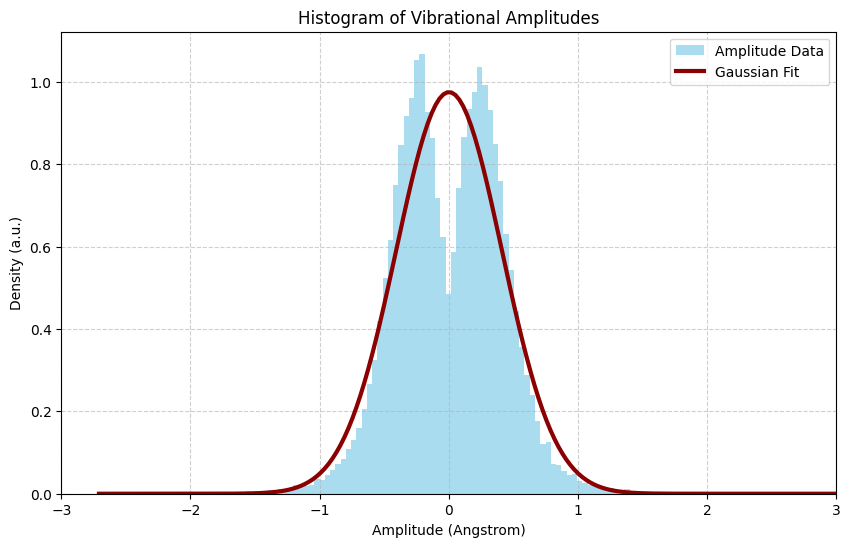

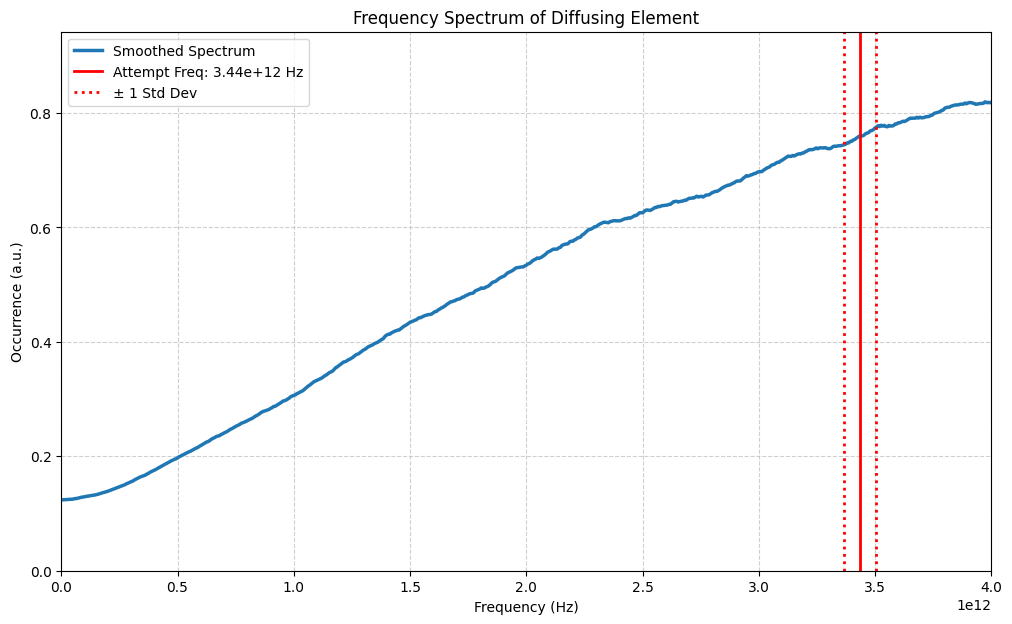

✅ Comprehensive vibrational analysis complete with all data saved

🔄 Discovering sites using TAOG method...

--- Stage 2: Discovering Sites from Time-Averaged Occupancy Grid ---
DEBUG: Building 100x100x100 occupancy grid...
DEBUG: Saved grid edges to /home/ram/Downloads/GO/test_package/analysis_output/occupancy_grid_edges.npy
DEBUG: Using density threshold of 110.87 to find peaks.
DEBUG: Found 48 potential sites.
DEBUG: Saved discovered site coordinates to /home/ram/Downloads/GO/test_package/analysis_output/discovered_sites_cart.npy
✅ Site discovery complete: 48 sites found


In [3]:
# --- 4. Calculate Tracer Properties (from MSD) ---
print("\n🔄 Analyzing tracer properties from MSD...")
tracer_analyzer = TracerPropertyAnalyzer(sim_data_obj)
tracer_results = tracer_analyzer.calculate_tracer_properties(
    diffusion_dim=diffusion_dimensionality,
    z_ion=ion_charge_z
)
print("✅ Tracer property analysis complete")

# --- 5. COMPREHENSIVE Vibrational Properties Analysis ---
print("\n🔄 Analyzing vibrational properties...")
vib_analyzer = VibrationAnalyzer()

# Run complete vibration analysis with data saving
attempt_freq, vibration_amp, std_freq = vib_analyzer.vibration_properties(
    sim_data_obj,
    show_pics=False,
    save_data=True,
    output_dir=output_data_path
)

# Get detailed vibration data
vib_data = vib_analyzer.get_vibration_data_only(sim_data_obj)
max_vib_amplitude = np.max(np.abs(vib_data['amplitude_data']))


# Generate additional custom plots
vib_analyzer.plot_amplitude_histogram_only(
    vib_data,
    bins=150,
    colors={'hist': 'skyblue', 'fit': 'darkred'},
    xlim=(-3.0, 3.0),
    output_file=f"{output_data_path}/custom_amplitude_hist.png"
)

vib_analyzer.plot_frequency_spectrum_only(
    vib_data,
    xlim=(0, 4.0e12),
    smooth_window=75,
    output_file=f"{output_data_path}/custom_frequency_spectrum.png"
)

# Store results in sim_data object
sim_data_obj.attempt_freq = attempt_freq
sim_data_obj.vibration_amp = vibration_amp
sim_data_obj.std_attempt_freq = std_freq
print("✅ Comprehensive vibrational analysis complete with all data saved")

# --- 6. Discover Sites from TAOG Density Grid ---
print("\n🔄 Discovering sites using TAOG method...")
site_finder = AmorphousSiteFinder(
    sim_data=sim_data_obj,
    grid_resolution=density_grid_resolution,
    save_path=output_data_path
)

discovered_sites_cartesian = site_finder.find_sites_from_density()
if discovered_sites_cartesian.size == 0:
    raise RuntimeError("❌ No sites were discovered. Check your parameters.")
print(f"✅ Site discovery complete: {len(discovered_sites_cartesian)} sites found")


🔄 Generating TAOG density visualization...
Plot saved to /home/ram/Downloads/GO/test_package/analysis_output/taog_density_plot.png
✅ TAOG visualization saved


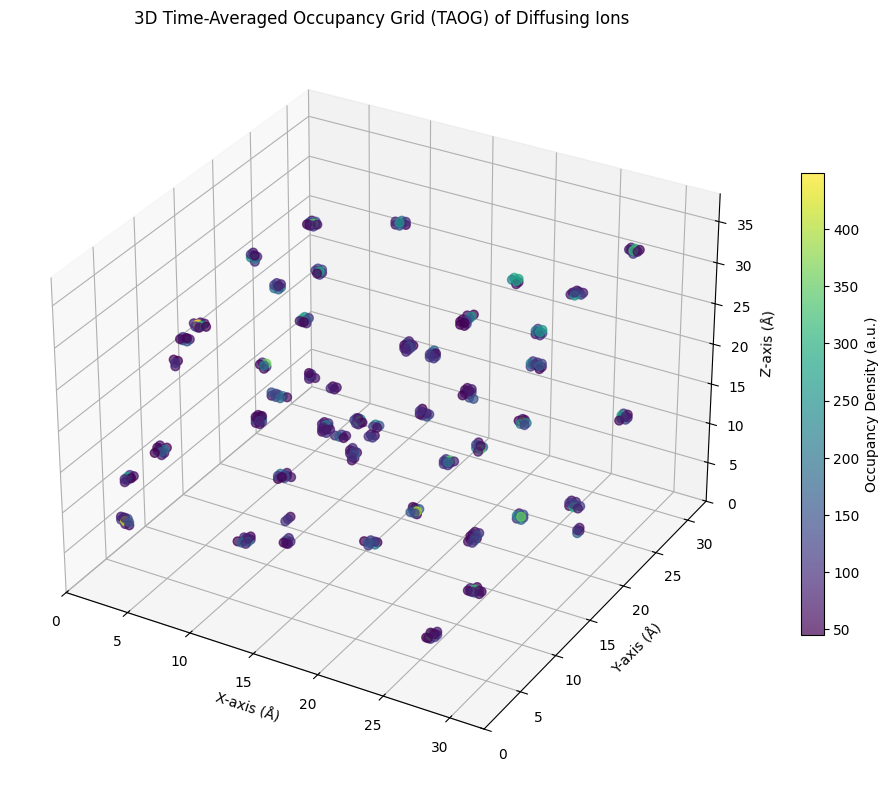

In [4]:
# --- 7. Visualize TAOG Density Grid ---
print("\n🔄 Generating TAOG density visualization...")
try:
    grid_file = os.path.join(output_data_path, 'occupancy_density_grid.npy')
    edges_file = os.path.join(output_data_path, 'occupancy_grid_edges.npy')
    
    if os.path.exists(grid_file) and os.path.exists(edges_file):
        density_grid = np.load(grid_file)
        edges = np.load(edges_file, allow_pickle=True)
        plot_output = os.path.join(output_data_path, 'taog_density_plot.png')
        plot_taog_density(density_grid, edges, threshold_ratio=0.1, output_file=plot_output)
        print("✅ TAOG visualization saved")
    else:
        print("⚠️ TAOG density files not found for visualization")
except Exception as e:
    print(f"⚠️ Could not generate TAOG visualization: {e}")


In [6]:
import numpy as np
from scipy.ndimage import maximum_filter, label as nd_label   # ← add this

# After site discovery ------------------------------------------------
density_grid, edges = site_finder._build_occupancy_grid()

# identify connected peak regions
labeled_peaks, num_features = nd_label(
    density_grid == maximum_filter(density_grid, footprint=np.ones((3, 3, 3)))
)

# compute radii (method you just added to AmorphousSiteFinder)
site_radii = site_finder.get_site_radii(
    labeled_peaks, num_features, edges, discovered_sites_cartesian
)

max_site_radius = site_radii.max()
print(f"Maximum site radius: {max_site_radius:.3f} Å")


DEBUG: Building 100x100x100 occupancy grid...
DEBUG: Saved grid edges to /home/ram/Downloads/GO/test_package/analysis_output/occupancy_grid_edges.npy


IndexError: index 48 is out of bounds for axis 0 with size 48

In [5]:
# After site discovery ------------------------------------------------
density_grid, edges = site_finder._build_occupancy_grid()
labeled_peaks, num_features = nd_label(density_grid == maximum_filter(
                                       density_grid, footprint=np.ones((3,3,3))))
site_radii = site_finder.get_site_radii(labeled_peaks, num_features,
                                        edges, discovered_sites_cartesian)

max_site_radius = site_radii.max()
print(f"Maximum site radius (95th percentile + ½ diag): {max_site_radius:.3f} Å")

# ---------------------------------------------------------------------
# Jump analysis --------------------------------------------------------
diff_atoms = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")
jump_analysis = SiteAnalyzerMDA(diff_atoms, discovered_sites_cartesian)

jump_analysis.site_radius = max_site_radius       # external override
jump_analysis.run(verbose=True)


DEBUG: Building 100x100x100 occupancy grid...
DEBUG: Saved grid edges to /home/ram/Downloads/GO/test_package/analysis_output/occupancy_grid_edges.npy


NameError: name 'nd_label' is not defined

In [ ]:
# --- After site discovery ---
print("\n🔄 Discovering sites and calculating site radii...")
site_finder = AmorphousSiteFinder(
    sim_data=sim_data_obj,
    grid_resolution=density_grid_resolution,
    save_path=output_data_path
)

# Find sites from density grid
discovered_sites_cartesian = site_finder.find_sites_from_density()

if discovered_sites_cartesian.size == 0:
    raise RuntimeError("❌ No sites discovered.")

# Load previously saved occupancy grid and edges (or build again if needed)
density_grid = np.load(f"{output_data_path}/occupancy_density_grid.npy")
edges = np.load(f"{output_data_path}/occupancy_grid_edges.npy", allow_pickle=True)

# Get labeled peaks and number of features for the grid peaks
labeled_peaks, num_features = site_finder._find_grid_peaks(density_grid)

# Calculate site radii based on voxel distances for each peak
site_radii = site_finder.find_site_radii(
    density_grid=density_grid,
    edges=edges,
    labeled_peaks=labeled_peaks,
    num_features=num_features,
    discovered_sites_cart=discovered_sites_cartesian
)

print(f"Max site radius from density peaks: {np.max(site_radii):.4f} Å")
print(f"Mean site radius: {np.mean(site_radii):.4f} Å")

# --- 8. Analyze Jumps Between Discovered Sites ---
print("\n🔄 Analyzing jumps between sites...")
diffusing_atoms_group = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")

jump_analysis = SiteAnalyzerMDA(
    diffusing_atom_group=diffusing_atoms_group,
    site_coordinates_cart=discovered_sites_cartesian
)

# Combine radius info: use max from density or vibration-based radius
max_site_radius = np.max(site_radii)

print(f"Setting site radius to the maximum site radius from density peaks: {max_site_radius:.4f} Å")

jump_analysis.site_radius = max_site_radius

jump_analysis.run(verbose=True)

num_jumps_found = len(jump_analysis.results.all_trans) if hasattr(jump_analysis.results, 'all_trans') else 0
print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")


In [ ]:
# --- 7. Visualize TAOG Density Grid ---
print("\n🔄 Generating TAOG density visualization...")
try:
    grid_file = os.path.join(output_data_path, 'occupancy_density_grid.npy')
    edges_file = os.path.join(output_data_path, 'occupancy_grid_edges.npy')
    
    if os.path.exists(grid_file) and os.path.exists(edges_file):
        density_grid = np.load(grid_file)
        edges = np.load(edges_file, allow_pickle=True)
        plot_output = os.path.join(output_data_path, 'taog_density_plot.png')
        plot_taog_density(density_grid, edges, threshold_ratio=0.1, output_file=plot_output)
        print("✅ TAOG visualization saved")
    else:
        print("⚠️ TAOG density files not found for visualization")
except Exception as e:
    print(f"⚠️ Could not generate TAOG visualization: {e}")
    
# --- 8. Analyze Jumps Between Discovered Sites ---
print("\n🔄 Analyzing jumps between sites...")
diffusing_atoms_group = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")
jump_analysis = SiteAnalyzerMDA(
    diffusing_atom_group=diffusing_atoms_group,
    site_coordinates_cart=discovered_sites_cartesian
)
# Set custom site radius based on vibration analysis
jump_analysis.site_radius = max(max_vib_amplitude, 2.0 * vibration_amp)
print(f"Setting site radius to: {jump_analysis.site_radius:.4f} Å")
print(f"  (Based on max vib: {max_vib_amplitude:.4f} Å, mean vib: {vibration_amp:.4f} Å)")

jump_analysis.run(verbose=True)
num_jumps_found = len(jump_analysis.results.all_trans) if hasattr(jump_analysis.results, 'all_trans') else 0
print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")

# --- 9. Calculate Jump Diffusivity ---
print("\n🔄 Calculating jump diffusivity...")
jump_diffusivity_val = 0.0
if num_jumps_found > 0:
    diffusivity_analyzer = JumpDiffusivityAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cartesian
    )
    
    jump_diffusivity_val = diffusivity_analyzer.calculate_jump_properties(
        show_plot=True,
        save_data=True,
        output_dir=output_data_path
    )
    
    diffusivity_analyzer.save_jump_summary(jump_diffusivity_val, output_data_path)
    print("✅ Jump diffusivity calculation complete with data saved")
else:
    print("⚠️ No jumps found - skipping jump diffusivity calculation")

# --- 10. Analyze Collective Jumps ---
print("\n🔄 Analyzing collective jump behavior...")
collective_results = None
if num_jumps_found > 0:
    collective_analyzer = CollectiveJumpAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cartesian,
        coll_dist=experimental_coll_dist,
        coll_steps_manual=experimental_coll_steps
    )
    
    collective_results = collective_analyzer.analyze()
    print("✅ Collective jump analysis complete")
else:
    print("⚠️ No jumps found - skipping collective jump analysis")

# --- 11. COMPREHENSIVE Migration Pathway Analysis ---
print("\n🛤️ Analyzing comprehensive migration pathways...")
if num_jumps_found > 0:
    migration_plotter = MigrationPathwayPlotter()
    
    # Generate all migration pathway analyses in one comprehensive call
    migration_analysis = migration_plotter.plot_comprehensive_migration_analysis(
        sites_cart=discovered_sites_cartesian,
        jump_data=jump_analysis.results.all_trans,
        min_probability=0.001,
        output_dir=output_data_path
    )
    
    print("✅ Comprehensive migration pathway analysis complete!")
    
    # Display key results
    prob_results = migration_analysis['migration_probabilities']
    pathway_results = migration_analysis['pathway_analysis']
    print(f"\n🛤️ MIGRATION PATHWAY RESULTS:")
    print(f" Total migration pathways: {pathway_results['total_edges']}")
    print(f" Most active source site: Site {pathway_results['most_central_out'][0]+1}")
    print(f" Most active sink site: Site {pathway_results['most_central_in'][0]+1}")
    print(f" Key bridge site: Site {pathway_results['most_between'][0]+1}")
    
    if pathway_results['high_probability_edges']:
        top_pathway = pathway_results['high_probability_edges'][0]
        print(f" Highest probability pathway: Site {top_pathway[0]+1} → Site {top_pathway[1]+1} ({top_pathway[2]:.4f})")
else:
    print("⚠️ No jumps found - skipping migration pathway analysis")

# --- 12. COMPREHENSIVE Activation Energy Analysis ---
print("\n⚡ Calculating comprehensive activation energies...")
if num_jumps_found > 0:
    sim_data_obj.temperature = temperature  # K
    activation_analyzer = ActivationEnergyAnalyzer(sim_data_obj)
    
    # Overall activation energy
    total_time = sim_data_obj.total_time
    effective_freq = num_jumps_found / (sim_data_obj.nr_diffusing * total_time)
    
    print(f"Validation check:")
    print(f" Effective frequency: {effective_freq:.2e} Hz")
    print(f" Attempt frequency: {sim_data_obj.attempt_freq:.2e} Hz")
    print(f" Frequency ratio: {effective_freq/sim_data_obj.attempt_freq:.4f}")

    # Site-specific activation energies
    
    site_energies = activation_analyzer.calculate_site_specific_activation_energies(
        jump_data=jump_analysis.results.all_trans,
        sites_cart=discovered_sites_cartesian,
        temperature=sim_data_obj.temperature,
        attempt_freq=sim_data_obj.attempt_freq
    )
        
    if site_energies:
        activation_analyzer.compare_activation_energies(
            site_energies,
            output_file=f"{output_data_path}/activation_energies_comparison.png"
        )
    
    if effective_freq/sim_data_obj.attempt_freq < 1.0:
        try:
            overall_activation = activation_analyzer.calculate_activation_energy_from_frequencies(
                effective_jump_freq=effective_freq,
                attempt_freq=sim_data_obj.attempt_freq,
                temperature=sim_data_obj.temperature
            )
            print(f"✅ Overall Activation Energy: {overall_activation['activation_energy_eV']:.3f} eV")
        except Exception as e:
            print(f"⚠️ Could not calculate overall activation energy: {e}")
    
    # Site-specific with occupancy corrections
    try:
        site_energies = activation_analyzer.calculate_activation_energies_with_occupancy(
            jump_analysis_results=jump_analysis,
            sites_cart=discovered_sites_cartesian,
            temperature=sim_data_obj.temperature
        )
        
        if site_energies:
            activation_analyzer.compare_activation_energies(
                site_energies,
                output_file=f"{output_data_path}/activation_energies_comparison.png"
            )
            
            activation_analyzer.generate_activation_energy_report(
                site_energies,
                output_file=f"{output_data_path}/activation_energy_report.txt"
            )
            
            print(f"✅ Site-specific activation energies calculated for {len(site_energies)} jump types")
    except Exception as e:
        print(f"⚠️ Site-specific activation energy calculation failed: {e}")
else:
    print("⚠️ No jumps found - skipping activation energy analysis")


In [ ]:
# --- 13. CONSOLIDATED Data Saving ---
print("\n💾 Saving all occupancy and jump data...")
jump_output_path = f"{output_data_path}/jump_output"
os.makedirs(jump_output_path, exist_ok=True)

if num_jumps_found > 0:
    # Save all data files with proper formatting
    site_occupancy_data = np.column_stack([
        np.arange(len(jump_analysis.results.site_occupancies)),
        jump_analysis.results.site_occupancies
    ])
    np.savetxt(f'{jump_output_path}/site_occupancies.txt',
               site_occupancy_data,
               header='Site_ID Average_Occupancy(atoms)',
               fmt='%d %.6f')
    
    occupancy_factor_data = np.column_stack([
        np.arange(len(jump_analysis.results.average_occupancy_factors)),
        jump_analysis.results.average_occupancy_factors
    ])
    np.savetxt(f'{jump_output_path}/occupancy_factors.txt',
               occupancy_factor_data,
               header='Site_ID Occupancy_Factor',
               fmt='%d %.6f')
    
    # Save residence time statistics
    with open(f'{jump_output_path}/residence_time_stats.txt', 'w') as f:
        f.write("Site_ID Mean_ResidenceTime(ps) Std_ResidenceTime Min_ResidenceTime Max_ResidenceTime Count\n")
        for site_idx in range(jump_analysis.n_sites):
            stats = jump_analysis.results.residence_time_stats[site_idx]
            f.write(f"{site_idx} {stats['mean']:.6f} {stats['std']:.6f} "
                   f"{stats['min']:.6f} {stats['max']:.6f} {stats['count']}\n")
    
    # Save jump events
    np.savetxt(f'{jump_output_path}/jump_events.txt', jump_analysis.results.all_trans,
               header='AtomIndex FromSite ToSite Time(ps)', fmt='%d %d %d %.6f')
    
    # Save jump-specific occupancy factors
    occupancy_factors = jump_analysis.get_jump_specific_occupancy_factors()
    with open(f'{jump_output_path}/jump_occupancy_factors.txt', 'w') as f:
        f.write("Jump_Type Occupancy_Factor\n")
        for jump_type, factor in occupancy_factors.items():
            f.write(f"{jump_type} {factor:.6f}\n")
    
    # Save comprehensive summary
    with open(f'{jump_output_path}/occupancy_summary.txt', 'w') as f:
        f.write("SITE OCCUPANCY SUMMARY\n")
        f.write("="*50 + "\n\n")
        f.write(f"Total Sites: {jump_analysis.n_sites}\n")
        f.write(f"Total Diffusing Atoms: {len(jump_analysis._ag)}\n")
        f.write(f"Total Jumps Detected: {len(jump_analysis.results.all_trans)}\n")
        f.write(f"Average Site Occupancy: {np.mean(jump_analysis.results.site_occupancies):.3f} atoms\n")
        f.write(f"Average Occupancy Factor: {np.mean(jump_analysis.results.average_occupancy_factors):.4f}\n\n")
        f.write("DETAILED SITE INFORMATION:\n")
        f.write("-" * 30 + "\n")
        f.write(f"{'Site_ID':<8} {'Avg_Occ':<10} {'Occ_Factor':<12} {'Residence_Events':<15}\n")
        f.write("-" * 50 + "\n")
        for site_idx in range(jump_analysis.n_sites):
            avg_occ = jump_analysis.results.site_occupancies[site_idx]
            occ_factor = jump_analysis.results.average_occupancy_factors[site_idx]
            res_events = jump_analysis.results.residence_time_stats[site_idx]['count']
            f.write(f"{site_idx:<8} {avg_occ:<10.3f} {occ_factor:<12.6f} {res_events:<15}\n")

print("✅ All data saved with proper formatting!")

# --- 14. CONSOLIDATED Collective Analysis Plotting ---
print("\n📊 Generating all collective analysis plots...")
if collective_results:
    coll_plotter = CollectivePlotter()
    coll_plotter.plot_all_collective_analyses(
        collective_results,
        jump_analysis.results.all_trans,
        timestep=sim_data_obj.time_step,
        output_dir=output_data_path
    )
    print("✅ All collective plots generated!")
else:
    print("⚠️ No collective results available - skipping collective plotting")

# --- 15. Additional Comprehensive Analyses ---
print("\n🔄 Running additional comprehensive analyses...")

# Connectivity Analysis
if num_jumps_found > 0:
    conn_plotter = ConnectivityPlotter()
    conn_plotter.plot_3d_site_connectivity(
        sites_cart=discovered_sites_cartesian,
        jump_data=jump_analysis.results.all_trans,
        min_jumps=1,
        edge_width_scale=8,
        node_size=150,
        show_site_labels=True,
        colormap='plasma',
        output_file=f"{output_data_path}/3d_site_connectivity.png"
    )

# Displacement Analysis
disp_plotter = DisplacementPlotter()
disp_plotter.plot_individual_displacements(
    sim_data_obj,
    timestep=sim_data_obj.time_step,
    max_atoms=50,
    output_file=f"{output_data_path}/individual_displacements.png"
)

disp_plotter.plot_displacement_histogram(
    sim_data_obj,
    bins=60,
    output_file=f"{output_data_path}/displacement_histogram.png"
)

disp_plotter.plot_3d_density_with_sites(
    sim_data_obj,
    sites_cart=discovered_sites_cartesian,
    resolution=0.2,
    iso_values=[0.8, 0.6, 0.3, 0.15, 0.05],
    colors=['red', 'orange', 'yellow'],
    alphas=[0.6, 0.4, 0.2],
    output_file=f"{output_data_path}/3d_density_with_sites.png"
)

# Van Hove Analysis
vanhove_analyzer = VanHoveAnalyzer(sim_data_obj, diffusing_element='Li')
time_lags = [10, 100, 300, 500, 700, 900]
# time_lags = [200, 2000, 6000, 10000, 14000, 18000]        # [10, 100, 300, 500, 700, 900]

vanhove_results = vanhove_analyzer.run_complete_analysis(
    time_lags=time_lags,
    max_r=None,
    n_bins=2000,
    output_dir=output_data_path
)

# Van Hove Plotting
vh_plotter = VanHovePlotter()
vh_plotter.plot_van_hove_functions(
    r_values=vanhove_results['r_values'],
    self_results=vanhove_results['self_normalized'],
    distinct_results=vanhove_results['distinct_normalized'],
    time_lags=vanhove_results['time_lags'],
    timestep=sim_data_obj.time_step,
    diffusing_element='Li',
    sigma=2.0,
    xlim=(0, 10),
    yscale='log',
    output_dir=output_data_path
)

print("✅ All additional analyses complete!")

# --- 16. FINAL COMPREHENSIVE RESULTS SUMMARY ---
print("\n" + "="*80)
print("📊 FINAL COMPREHENSIVE ANALYSIS RESULTS")
print("="*80)

# Basic statistics
print(f"📈 BASIC STATISTICS:")
print(f" Number of Jump Sites Found: {len(discovered_sites_cartesian)}")
print(f" Total Jumps Detected: {num_jumps_found}")
print(f" Simulation Time: {sim_data_obj.total_time:.2e} s")
print(f" Number of Frames: {sim_data_obj.nr_steps}")

# Diffusion properties
print(f"\n🔬 DIFFUSION PROPERTIES:")
print(f" Tracer Diffusivity (MSD): {tracer_results['tracer_diffusivity']:.4e} m²/s")
print(f" Jump Diffusivity: {jump_diffusivity_val:.4e} m²/s")
print(f" Particle Density: {tracer_results['particle_density']:.4e} particles/m³")
print(f" Concentration: {tracer_results['mol_per_liter']:.4f} mol/L")

# Electrical properties
print(f"\n⚡ ELECTRICAL PROPERTIES:")
print(f" Tracer Conductivity: {tracer_results['tracer_conductivity']:.4e} S/m")
print(f" Ion Charge: {ion_charge_z} e")
print(f" Temperature: {sim_data_obj.temperature} K")

# Dynamic properties
print(f"\n🌊 DYNAMIC PROPERTIES:")
print(f" Jump Frequency: {attempt_freq:.2e} ± {std_freq:.1e} Hz")
print(f" Vibration Amplitude: {vibration_amp:.4f} Å")
print(f" Mean Squared Displacement: {tracer_results['msd']:.4f} Å²")

# Collective behavior
print(f"\n🤝 COLLECTIVE BEHAVIOR:")
if collective_results:
    num_coll_pairs = len(collective_results.get('collective_pairs', []))
    num_multi_jumps = len(collective_results.get('multi_collective_jumps', []))
    uncoll_count = collective_results.get('uncollective_count', 0)
    print(f" Collective Jump Pairs: {num_coll_pairs}")
    print(f" Multi-Correlated Jumps: {num_multi_jumps}")
    print(f" Uncorrelated Jumps: {uncoll_count}")
    print(f" Collective Fraction: {num_coll_pairs*2/(num_jumps_found or 1):.1%}")
else:
    print(f" Collective Jump Pairs: 0 (no jumps or analysis skipped)")

# Van Hove Analysis Results
print(f"\n📊 VAN HOVE ANALYSIS:")
print(f" Particles analyzed: {vanhove_results['analysis_parameters']['n_particles']}")
print(f" Frames analyzed: {vanhove_results['analysis_parameters']['n_frames']}")
print(f" Maximum distance: {vanhove_results['analysis_parameters']['max_r']:.2f} Å")
print(f" Time lags analyzed: {vanhove_results['time_lags']}")

# Jump details
if num_jumps_found > 0:
    print(f"\n🎯 JUMP DETAILS:")
    print(f" Site Radius for Jump Detection: {getattr(jump_analysis, 'site_radius', 'N/A')} Å")
    print(f" Average Jumps per Atom: {num_jumps_found/sim_data_obj.nr_diffusing:.2f}")
    print(f" Jump Rate: {num_jumps_found/sim_data_obj.total_time:.2e} jumps/s")
    
    print(f"\n Example Jump Events (first 5):")
    print(f" {'Atom':<6} {'From':<6} {'To':<6} {'Time (ps)':<12}")
    print(f" {'-'*30}")
    for i, jump in enumerate(jump_analysis.results.all_trans[:5]):
        atom_idx, from_site, to_site, time_ps = jump
        print(f" {int(atom_idx):<6} {int(from_site):<6} {int(to_site):<6} {time_ps:<12.2f}")

# File outputs
print(f"\n📁 OUTPUT FILES GENERATED:")
print(f" Analysis Directory: {output_data_path}")
print(f" ✓ Site Coordinates: discovered_sites_cart.npy")
print(f" ✓ Density Grid: occupancy_density_grid.npy")
print(f" ✓ TAOG Visualization: taog_density_plot.png")
print(f" ✓ Migration Pathways: comprehensive migration analysis")
print(f" ✓ Collective Analysis: all collective plots")
print(f" ✓ Van Hove Functions: g_self_rt.dat, g_distinct_rt.dat")
print(f" ✓ Activation Energies: activation_energies_comparison.png")
print(f" ✓ Jump Data: All occupancy and jump files in jump_output/")

print("\n✅ COMPLETE COMPREHENSIVE ANALYSIS FINISHED!")
print("="*80)